In [1]:
# Standard libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Own libraries
from my_fun.my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'

# Intro

In [5]:
def psychophysical_kernel(n_points=100, mode='perfect', noise_std=0.05, tau=1/3):
    """
    Exponential psychophysical kernels:
    - primacy  ~ exp(-x / tau)
    - recency  ~ exp(-(1 - x) / tau)
    """

    x = np.linspace(0, 1, n_points)

    if mode == 'perfect':
        k = np.ones_like(x)

    elif mode == 'primacy':
        # strong early weighting (decay over time)
        k = np.exp(-x / tau)

    elif mode == 'recency':
        # strong late weighting (mirror of primacy)
        k = np.exp(-(1 - x) / tau)

    else:
        raise ValueError('mode must be perfect, primacy, or recency')

    # add noise
    k = k + np.random.normal(0, noise_std, size=n_points)
    k[k < 0] = 0

    # normalize to [0, 1]
    k = (k - k.min()) / (k.max() - k.min())

    # center mean at 0
    k = k - k.mean() + 0.5

    return x, k

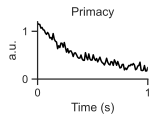

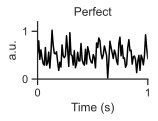

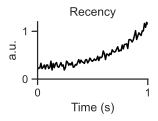

In [12]:
# Plot all three kernels
for mode, color, title in zip(['primacy', 'perfect', 'recency'], ['k', 'k', 'k'], ['Primacy', 'Perfect', 'Recency']):
    figsize = fig_size(n_cols=3)
    plt.figure(figsize=figsize, constrained_layout=True)
    x, k = psychophysical_kernel(mode=mode)
    plt.plot(x, k, label=mode.capitalize(), color=color)
    plt.xlim(0, 1)
    plt.ylim(0, 1.2)
    plt.xticks([0, 1], ['0', '1'])
    plt.yticks([0, 1], ['0', '1'])
    plt.xlabel('Time (s)')
    plt.ylabel('a.u.')
    plt.title(title)
    sns.despine()

# Save all notebook's figures

In [13]:
# # Whole notebook ouputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files('notebook.ipynb')

Saved 3 images to notebook_files/


# Results

This notebook is used to generate the results for the thesis. It is not meant to be run as a script, but rather to be used as a reference for the results presented in the thesis.

## Results I: Behavioral analyses

First, we need to load the data of the different groups of animals and merge them together in a single DataFrame.

### Learning Curves

### Licks

### Reaction Times

### Psychometric Curves

### Psychophysical Kernels

### History Kernels

### Hidden Markov Models

## Results II: Behavioral analyses + Drugs

## Results III: Electrophysiological analyses